# 02 · Model experiments

**Plan**
1. Load **half of the training data** and train **10 classical models** with base settings.
2. Keep the **top 3** by validation weighted F1.
3. **Tune** their hyperparameters on the **full training data**.
4. Pick the **best model** and make it the project's main model (`main.py train` and `main.py predict`).

**Rules that keep the scores honest**
- Every decision uses `train.csv` only. Scores come from the 5 folds stored in the preprocess stage (stratified by
  label, grouped by comment text), so all models see identical splits. `test.csv` is used only at the very end, by the
  project's `predict` stage, to write `predictions.csv`.
- Feature transformers (TF-IDF, SVD, scalers, one-hot) are fitted on the training folds only, then applied to the
  validation fold.
- Each model is scored on its training folds and on the validation folds. A large gap means overfitting.

**Metrics** (the capstone's primary metric is weighted F1)

| Metric | Why |
|---|---|
| Weighted F1 | Primary metric of the capstone |
| Macro F1 | Weighs the small positive and negative classes equally; a high weighted F1 can hide weak minority classes |
| Accuracy | Easy to read, but inflated by the 72% neutral class |
| Macro recall | Share of each class that is found, averaged over the three classes |
| ROC AUC (one-vs-rest, weighted) | How well the class scores rank rows; needs scores, not predicted labels |

In [1]:
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

from drug_sentiment.config import get_config
from drug_sentiment.models.features import TEXT_COLUMN, build_features, load_model_frame
from drug_sentiment.models.train import BEST_CONFIG_FILE, run_prediction, run_training
from drug_sentiment.utils.io import save_json
from drug_sentiment.visualization import model_plots
from drug_sentiment.visualization.style import apply_style, save_figure

apply_style()
optuna.logging.set_verbosity(optuna.logging.WARNING)

cfg = get_config()
SEED, N_JOBS = cfg.seed, cfg.n_jobs
frame = load_model_frame("train", cfg)  # preprocessed train rows + MiniLM embedding columns
y = frame[cfg.data.target_col].to_numpy()
label_names = [cfg.data.label_names[label] for label in (0, 1, 2)]
print(f"Full training data: {len(frame):,} rows, {frame.shape[1]} columns; text input: {TEXT_COLUMN}")

E:\AV_Capstone_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Full training data: 5,279 rows, 413 columns; text input: ctx_k1


## 1. Load half of the training data

A stratified 50% sample keeps the class proportions of the full data. It is used only to screen the 10 models
quickly. Rows keep their stored fold id, so cross-validation inside the half still never splits one comment across
training and validation.

In [2]:
half_index, _ = train_test_split(frame.index, train_size=0.5, stratify=y, random_state=SEED)
half = frame.loc[np.sort(half_index)].reset_index(drop=True)
y_half = half[cfg.data.target_col].to_numpy()

display(pd.DataFrame({
    "full train": pd.Series(y).map(cfg.data.label_names).value_counts(normalize=True),
    "half sample": pd.Series(y_half).map(cfg.data.label_names).value_counts(normalize=True),
}).round(3))
print(f"Half sample: {len(half):,} rows; rows per fold: {np.bincount(half['fold']).tolist()}")

,full train,half sample
neutral,0.725,0.725
negative,0.159,0.158
positive,0.117,0.117


Half sample: 2,639 rows; rows per fold: [521, 532, 522, 524, 540]


## 2. The 10 models

Base settings are sensible defaults, not tuned yet. The labels are imbalanced (72% neutral), so models that support
it use `class_weight="balanced"`. GradientBoosting and XGBoost have no such option and get the equivalent balanced
sample weights when fitting; KNN has neither, and ComplementNB is built for imbalanced text.

Each model family receives the features in the shape it works best with (built by
`src/drug_sentiment/models/features.py`, the same code the main project uses):

| Representation | What it contains | Models |
|---|---|---|
| `sparse` | word 1–2-gram and character 2–5-gram TF-IDF of the drug window, log-scaled counts, scaled features, one-hot drug, MiniLM embedding | LogisticRegression, LinearSVC |
| `dense` | the same, with the TF-IDF compressed to 300 SVD components and every column standardised | SVC, KNN, DecisionTree, RandomForest, GradientBoosting, LightGBM, XGBoost |
| `counts` | TF-IDF and one-hot drug only (non-negative) | ComplementNB |

In [3]:
models = {
    "LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=5000),
    "LinearSVC": LinearSVC(C=0.1, class_weight="balanced", max_iter=20000),
    "ComplementNB": ComplementNB(alpha=0.3),
    "SVC": SVC(class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=N_JOBS),
    "DecisionTree": DecisionTreeClassifier(max_depth=12, min_samples_leaf=5, class_weight="balanced",
                                           random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample",
                                           n_jobs=N_JOBS, random_state=SEED),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=150, subsample=0.8, max_features="sqrt",
                                                   random_state=SEED),
    "LightGBM": LGBMClassifier(n_estimators=400, learning_rate=0.05, colsample_bytree=0.5, subsample=0.8,
                               subsample_freq=1, class_weight="balanced", n_jobs=N_JOBS, random_state=SEED,
                               verbose=-1),
    "XGBoost": XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8,
                             colsample_bytree=0.5, tree_method="hist", max_bin=64, n_jobs=N_JOBS,
                             random_state=SEED),
}

representation = {
    "LogisticRegression": "sparse", "LinearSVC": "sparse", "ComplementNB": "counts",
    "SVC": "dense", "KNN": "dense", "DecisionTree": "dense", "RandomForest": "dense",
    "GradientBoosting": "dense", "LightGBM": "dense", "XGBoost": "dense",
}

NEEDS_SAMPLE_WEIGHT = {"GradientBoosting", "XGBoost"}  # no class_weight option: balanced sample weights instead

## 3. Helper functions

- `validation()` is the evaluation function adapted to three classes: recall is averaged over the classes and ROC AUC
  is computed from class scores (one-vs-rest), not from predicted labels.
- `make_fold_data()` fits a fresh feature transformer on each training fold and transforms that fold's validation
  rows, so no validation row influences the features.
- `run_cv()` trains a copy of a model on each training fold, predicts the validation fold, and returns the training
  scores, the validation (out-of-fold) scores and the timing.

In [4]:
METRICS = ["accuracy", "f1_weighted", "f1_macro", "recall_macro", "roc_auc_ovr"]


def class_scores(model, X):
    """Per-class scores that sum to 1. LinearSVC and SVC have no predict_proba, so their decision values go
    through a softmax."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    decision = model.decision_function(X)
    decision = decision - decision.max(axis=1, keepdims=True)
    return np.exp(decision) / np.exp(decision).sum(axis=1, keepdims=True)


def validation(true, predicted, scores):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted, average="weighted")
    f1_macro = f1_score(true, predicted, average="macro")
    recall = recall_score(true, predicted, average="macro")
    roc = roc_auc_score(true, scores, multi_class="ovr", average="weighted")
    return acc, f1, f1_macro, recall, roc


def make_fold_data(data, representation_name):
    fold_ids = data["fold"].to_numpy()
    fold_data = []
    for fold in np.unique(fold_ids):
        train_idx, val_idx = np.flatnonzero(fold_ids != fold), np.flatnonzero(fold_ids == fold)
        features = build_features(representation_name, seed=SEED)
        X_train = features.fit_transform(data.iloc[train_idx])
        fold_data.append((train_idx, val_idx, X_train, features.transform(data.iloc[val_idx])))
    return fold_data


def run_cv(name, model, fold_data, labels, score_train=True, after_fold=None):
    oof_pred = np.zeros(len(labels), dtype=int)
    oof_scores = np.zeros((len(labels), 3))
    train_scores, fold_f1 = [], []
    start = time.perf_counter()
    for step, (train_idx, val_idx, X_train, X_val) in enumerate(fold_data):
        estimator = clone(model)
        fit_params = {}
        if name in NEEDS_SAMPLE_WEIGHT:
            fit_params["sample_weight"] = compute_sample_weight("balanced", labels[train_idx])
        estimator.fit(X_train, labels[train_idx], **fit_params)

        oof_pred[val_idx] = estimator.predict(X_val)
        oof_scores[val_idx] = class_scores(estimator, X_val)
        fold_f1.append(f1_score(labels[val_idx], oof_pred[val_idx], average="weighted"))
        if score_train:
            train_pred = estimator.predict(X_train)
            train_scores.append(validation(labels[train_idx], train_pred, class_scores(estimator, X_train)))
        if after_fold is not None:  # used by tuning to stop weak trials early
            after_fold(step, float(np.mean(fold_f1)))
    return {
        "train": np.mean(train_scores, axis=0) if score_train else None,
        "valid": validation(labels, oof_pred, oof_scores),
        "fold_f1_std": float(np.std(fold_f1)),
        "oof_pred": oof_pred,
        "seconds": time.perf_counter() - start,
    }

## 4. Base training of all 10 models on half of the data

In [5]:
half_folds = {}
for representation_name in ("sparse", "dense", "counts"):
    start = time.perf_counter()
    half_folds[representation_name] = make_fold_data(half, representation_name)
    n_features = half_folds[representation_name][0][2].shape[1]
    print(f"{representation_name:6s}: {n_features:,} features, 5 folds prepared in {time.perf_counter() - start:.0f}s")

sparse: 38,491 features, 5 folds prepared in 15s


dense : 736 features, 5 folds prepared in 94s


counts: 38,091 features, 5 folds prepared in 13s


In [6]:
screening = {}

for name, model in models.items():
    result = run_cv(name, model, half_folds[representation[name]], y_half)
    screening[name] = result

    model_tr_acc, model_tr_f1, model_tr_f1_macro, model_tr_re, model_tr_roc = result["train"]
    model_va_acc, model_va_f1, model_va_f1_macro, model_va_re, model_va_roc = result["valid"]

    print('Model selection for "Training Dataset" ->', name)
    print('Accuracy : {:.4f}'.format(model_tr_acc))
    print('F1 Score (weighted): {:.4f}'.format(model_tr_f1))
    print('F1 Score (macro): {:.4f}'.format(model_tr_f1_macro))
    print('Recall Score (macro): {:.4f}'.format(model_tr_re))
    print('ROC AUC Score : {:.4f}'.format(model_tr_roc))

    print('-------------------------------------------------------------')

    print('Model selection for "Validation Dataset" ->', name)
    print('Accuracy : {:.4f}'.format(model_va_acc))
    print('F1 Score (weighted): {:.4f}'.format(model_va_f1))
    print('F1 Score (macro): {:.4f}'.format(model_va_f1_macro))
    print('Recall Score (macro): {:.4f}'.format(model_va_re))
    print('ROC AUC Score : {:.4f}'.format(model_va_roc))
    print('Time: {:.0f}s for 5 folds'.format(result["seconds"]))

    print('=============================================================')

Model selection for "Training Dataset" -> LogisticRegression
Accuracy : 0.9308
F1 Score (weighted): 0.9330
F1 Score (macro): 0.9079
Recall Score (macro): 0.9674
ROC AUC Score : 0.9932
-------------------------------------------------------------
Model selection for "Validation Dataset" -> LogisticRegression
Accuracy : 0.6908
F1 Score (weighted): 0.7024
F1 Score (macro): 0.5544
Recall Score (macro): 0.5757
ROC AUC Score : 0.7750
Time: 22s for 5 folds


Model selection for "Training Dataset" -> LinearSVC
Accuracy : 0.9427
F1 Score (weighted): 0.9432
F1 Score (macro): 0.9166
Recall Score (macro): 0.9283
ROC AUC Score : 0.9827
-------------------------------------------------------------
Model selection for "Validation Dataset" -> LinearSVC
Accuracy : 0.7298
F1 Score (weighted): 0.7214
F1 Score (macro): 0.5543
Recall Score (macro): 0.5429
ROC AUC Score : 0.7768
Time: 19s for 5 folds


Model selection for "Training Dataset" -> ComplementNB
Accuracy : 0.8913
F1 Score (weighted): 0.8840
F1 Score (macro): 0.8120
Recall Score (macro): 0.7566
ROC AUC Score : 0.9474
-------------------------------------------------------------
Model selection for "Validation Dataset" -> ComplementNB
Accuracy : 0.7382
F1 Score (weighted): 0.6792
F1 Score (macro): 0.4323
Recall Score (macro): 0.4222
ROC AUC Score : 0.6875
Time: 0s for 5 folds


Model selection for "Training Dataset" -> SVC
Accuracy : 0.9581
F1 Score (weighted): 0.9590
F1 Score (macro): 0.9444
Recall Score (macro): 0.9803
ROC AUC Score : 0.9958
-------------------------------------------------------------
Model selection for "Validation Dataset" -> SVC
Accuracy : 0.6934
F1 Score (weighted): 0.7002
F1 Score (macro): 0.5453
Recall Score (macro): 0.5602
ROC AUC Score : 0.7589
Time: 47s for 5 folds


Model selection for "Training Dataset" -> KNN
Accuracy : 1.0000
F1 Score (weighted): 1.0000
F1 Score (macro): 1.0000
Recall Score (macro): 1.0000
ROC AUC Score : 1.0000
-------------------------------------------------------------
Model selection for "Validation Dataset" -> KNN
Accuracy : 0.7363
F1 Score (weighted): 0.6592
F1 Score (macro): 0.3800
Recall Score (macro): 0.3891
ROC AUC Score : 0.6963
Time: 2s for 5 folds


Model selection for "Training Dataset" -> DecisionTree
Accuracy : 0.8470
F1 Score (weighted): 0.8558
F1 Score (macro): 0.8094
Recall Score (macro): 0.9147
ROC AUC Score : 0.9677
-------------------------------------------------------------
Model selection for "Validation Dataset" -> DecisionTree
Accuracy : 0.5415
F1 Score (weighted): 0.5736
F1 Score (macro): 0.4193
Recall Score (macro): 0.4514
ROC AUC Score : 0.5839
Time: 6s for 5 folds


Model selection for "Training Dataset" -> RandomForest
Accuracy : 0.9990
F1 Score (weighted): 0.9990
F1 Score (macro): 0.9986
Recall Score (macro): 0.9995
ROC AUC Score : 1.0000
-------------------------------------------------------------
Model selection for "Validation Dataset" -> RandomForest
Accuracy : 0.7366
F1 Score (weighted): 0.6425
F1 Score (macro): 0.3465
Recall Score (macro): 0.3671
ROC AUC Score : 0.7524
Time: 24s for 5 folds


Model selection for "Training Dataset" -> GradientBoosting
Accuracy : 0.9758
F1 Score (weighted): 0.9762
F1 Score (macro): 0.9669
Recall Score (macro): 0.9889
ROC AUC Score : 0.9994
-------------------------------------------------------------
Model selection for "Validation Dataset" -> GradientBoosting
Accuracy : 0.7025
F1 Score (weighted): 0.7018
F1 Score (macro): 0.5333
Recall Score (macro): 0.5334
ROC AUC Score : 0.7548
Time: 30s for 5 folds


Model selection for "Training Dataset" -> LightGBM
Accuracy : 0.9999
F1 Score (weighted): 0.9999
F1 Score (macro): 0.9999
Recall Score (macro): 1.0000
ROC AUC Score : 1.0000
-------------------------------------------------------------
Model selection for "Validation Dataset" -> LightGBM
Accuracy : 0.7533
F1 Score (weighted): 0.7002
F1 Score (macro): 0.4710
Recall Score (macro): 0.4491
ROC AUC Score : 0.7693
Time: 129s for 5 folds


Model selection for "Training Dataset" -> XGBoost
Accuracy : 0.9997
F1 Score (weighted): 0.9997
F1 Score (macro): 0.9996
Recall Score (macro): 0.9999
ROC AUC Score : 1.0000
-------------------------------------------------------------
Model selection for "Validation Dataset" -> XGBoost
Accuracy : 0.7552
F1 Score (weighted): 0.7093
F1 Score (macro): 0.4903
Recall Score (macro): 0.4644
ROC AUC Score : 0.7782
Time: 92s for 5 folds


,representation,train_accuracy,train_f1_weighted,train_f1_macro,train_recall_macro,train_roc_auc_ovr,valid_accuracy,valid_f1_weighted,valid_f1_macro,valid_recall_macro,valid_roc_auc_ovr,fold_f1_std,seconds
LinearSVC,sparse,0.9427,0.9432,0.9166,0.9283,0.9827,0.7298,0.7214,0.5543,0.5429,0.7768,0.0162,18.9917
XGBoost,dense,0.9997,0.9997,0.9996,0.9999,1.0000,0.7552,0.7093,0.4903,0.4644,0.7782,0.0173,91.6397
LogisticRegression,sparse,0.9308,0.9330,0.9079,0.9674,0.9932,0.6908,0.7024,0.5544,0.5757,0.7750,0.0059,21.7177
GradientBoosting,dense,0.9758,0.9762,0.9669,0.9889,0.9994,0.7025,0.7018,0.5333,0.5334,0.7548,0.0140,30.3858
SVC,dense,0.9581,0.9590,0.9444,0.9803,0.9958,0.6934,0.7002,0.5453,0.5602,0.7589,0.0176,47.1363
LightGBM,dense,0.9999,0.9999,0.9999,1.0000,1.0000,0.7533,0.7002,0.4710,0.4491,0.7693,0.0235,129.3659
ComplementNB,counts,0.8913,0.8840,0.8120,0.7566,0.9474,0.7382,0.6792,0.4323,0.4222,0.6875,0.0238,0.3814
KNN,dense,1.0000,1.0000,1.0000,1.0000,1.0000,0.7363,0.6592,0.3800,0.3891,0.6963,0.0223,2.0249
RandomForest,dense,0.9990,0.9990,0.9986,0.9995,1.0000,0.7366,0.6425,0.3465,0.3671,0.7524,0.0151,23.5897
DecisionTree,dense,0.8470,0.8558,0.8094,0.9147,0.9677,0.5415,0.5736,0.4193,0.4514,0.5839,0.0262,6.0300


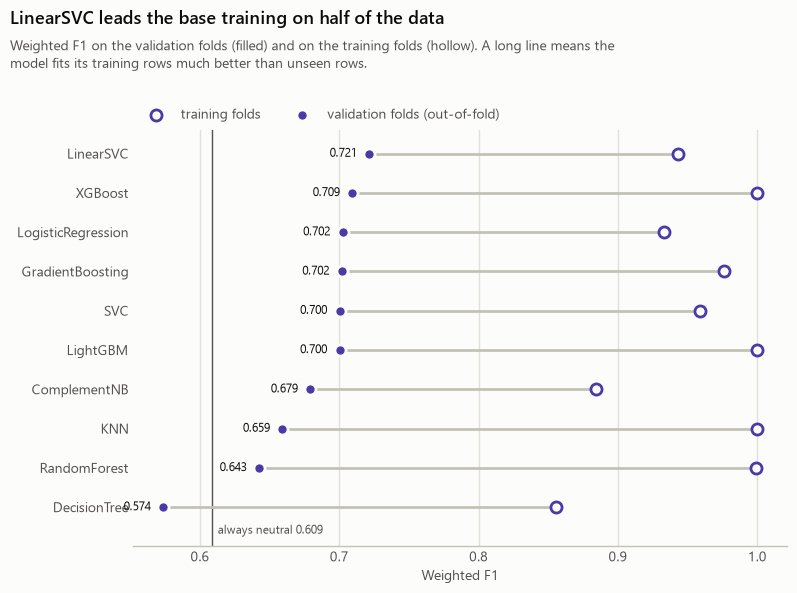

In [7]:
screening_table = pd.DataFrame({
    name: {
        "representation": representation[name],
        **{f"train_{metric}": value for metric, value in zip(METRICS, result["train"])},
        **{f"valid_{metric}": value for metric, value in zip(METRICS, result["valid"])},
        "fold_f1_std": result["fold_f1_std"],
        "seconds": result["seconds"],
    }
    for name, result in screening.items()
}).T
numeric_columns = screening_table.columns.drop("representation")
screening_table[numeric_columns] = screening_table[numeric_columns].astype(float)
screening_table = screening_table.sort_values(["valid_f1_weighted", "valid_f1_macro"], ascending=False)
screening_table.to_csv(cfg.artifacts.reports_dir / "model_screening_half.csv")
display(screening_table.round(4))

majority_f1 = f1_score(y_half, np.full(len(y_half), 2), average="weighted")
fig = model_plots.plot_model_comparison(
    screening_table.rename(columns={"valid_f1_weighted": "cv_f1_weighted"}), majority_f1,
    title=f"{screening_table.index[0]} leads the base training on half of the data",
    subtitle="Weighted F1 on the validation folds (filled) and on the training folds (hollow). "
             "A long line means the model fits its training rows much better than unseen rows.",
)
save_figure(fig, "model_screening_half")
plt.show()

## 5. Top 3 models

In [8]:
top3 = screening_table.index[:3].tolist()
gap = (screening_table["train_f1_weighted"] - screening_table["valid_f1_weighted"]).sort_values(ascending=False)
best_macro = screening_table["valid_f1_macro"].idxmax()
below_baseline = screening_table.index[screening_table["valid_f1_weighted"] <= majority_f1].tolist()

display(Markdown(
    "**Findings**\n\n"
    "- Top 3 by validation weighted F1: "
    + ", ".join(f"`{name}` ({screening_table.loc[name, 'valid_f1_weighted']:.3f})" for name in top3) + ".\n"
    f"- Best macro F1 (small classes): `{best_macro}` ({screening_table.loc[best_macro, 'valid_f1_macro']:.3f}).\n"
    f"- Largest overfitting gap: `{gap.index[0]}`, training F1 "
    f"{screening_table.loc[gap.index[0], 'train_f1_weighted']:.3f} vs validation "
    f"{screening_table.loc[gap.index[0], 'valid_f1_weighted']:.3f}.\n"
    f"- Not better than always predicting neutral ({majority_f1:.3f}): "
    + (", ".join(f"`{name}`" for name in below_baseline) if below_baseline else "none") + "."
))

**Findings**

- Top 3 by validation weighted F1: `LinearSVC` (0.721), `XGBoost` (0.709), `LogisticRegression` (0.702).
- Best macro F1 (small classes): `LogisticRegression` (0.554).
- Largest overfitting gap: `RandomForest`, training F1 0.999 vs validation 0.643.
- Not better than always predicting neutral (0.609): `DecisionTree`.

## 6. Hyperparameter tuning of the top 3 on the full training data

[Optuna](https://optuna.org) searches each model's hyperparameters:
- **TPE sampler** (seeded): proposes new values close to the best ones found so far.
- **Objective:** 5-fold out-of-fold weighted F1 on the full training data.
- **Median pruning:** a trial stops early when, after any fold, its running F1 is below the median of earlier trials
  at that fold, so clearly worse settings don't use a full 5-fold run.
- **Budget:** up to 30 trials or 10 minutes per model on this laptop CPU.
- The base settings are scored on the same folds first; if no trial beats them, they are kept.

Tuning and selection use the same folds, so the tuned scores are slightly optimistic. That is acceptable for
choosing between models; `test.csv` plays no part.

In [9]:
param_spaces = {
    "LogisticRegression": lambda trial: {
        "C": trial.suggest_float("C", 0.05, 20, log=True),
    },
    "LinearSVC": lambda trial: {
        "C": trial.suggest_float("C", 0.01, 3, log=True),
    },
    "ComplementNB": lambda trial: {
        "alpha": trial.suggest_float("alpha", 0.05, 2, log=True),
        "norm": trial.suggest_categorical("norm", [False, True]),
    },
    "SVC": lambda trial: {
        "C": trial.suggest_float("C", 0.3, 30, log=True),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"]),
    },
    "KNN": lambda trial: {
        "n_neighbors": trial.suggest_int("n_neighbors", 5, 60),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_categorical("p", [1, 2]),
    },
    "DecisionTree": lambda trial: {
        "max_depth": trial.suggest_int("max_depth", 4, 30),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
    },
    "RandomForest": lambda trial: {
        "n_estimators": trial.suggest_int("n_estimators", 300, 900, step=100),
        "max_depth": trial.suggest_int("max_depth", 8, 40),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3]),
    },
    "GradientBoosting": lambda trial: {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    },
    "LightGBM": lambda trial: {
        "n_estimators": trial.suggest_int("n_estimators", 300, 900, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 48),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.9),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 20, log=True),
    },
    "XGBoost": lambda trial: {
        "n_estimators": trial.suggest_int("n_estimators", 300, 900, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 20, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.9),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 20, log=True),
    },
}

In [10]:
N_TRIALS, TIMEOUT_SECONDS = 30, 10 * 60

full_folds = {}
for representation_name in sorted({representation[name] for name in top3}):
    start = time.perf_counter()
    full_folds[representation_name] = make_fold_data(frame, representation_name)
    print(f"{representation_name:6s}: full-data folds prepared in {time.perf_counter() - start:.0f}s")


def tune(name, fold_data):
    def objective(trial):
        candidate = clone(models[name]).set_params(**param_spaces[name](trial))

        def stop_if_weak(step, running_f1):
            trial.report(running_f1, step)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return run_cv(name, candidate, fold_data, y, score_train=False, after_fold=stop_if_weak)["valid"][1]

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    )
    study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_SECONDS)
    return study


tuned_models, tuned_results, trial_tables = {}, {}, []
for name in top3:
    fold_data = full_folds[representation[name]]
    base_f1 = run_cv(name, models[name], fold_data, y, score_train=False)["valid"][1]
    study = tune(name, fold_data)
    trials = study.trials_dataframe()
    trial_tables.append(trials.assign(model=name))

    improved = study.best_value > base_f1
    tuned_models[name] = clone(models[name]).set_params(**study.best_params) if improved else models[name]
    tuned_results[name] = run_cv(name, tuned_models[name], fold_data, y)
    tuned_results[name]["base_f1_weighted"] = base_f1

    print(f"{name}: {len(trials)} trials {trials['state'].value_counts().to_dict()}")
    print(f"  base settings F1 {base_f1:.4f} -> best trial {study.best_value:.4f}")
    print(f"  kept: {study.best_params if improved else 'base settings (no trial beat them)'}")

pd.concat(trial_tables).to_csv(cfg.artifacts.reports_dir / "tuning_trials.csv", index=False)

dense : full-data folds prepared in 173s


sparse: full-data folds prepared in 26s


LinearSVC: 4 trials {'COMPLETE': 4}
  base settings F1 0.7251 -> best trial 0.7274
  kept: {'C': 0.08468008575248333}


XGBoost: 5 trials {'COMPLETE': 5}
  base settings F1 0.7077 -> best trial 0.7148
  kept: {'n_estimators': 700, 'learning_rate': 0.021962256150304792, 'max_depth': 6, 'min_child_weight': 1.6666983286066417, 'subsample': 0.6260206371941118, 'colsample_bytree': 0.8693313223520001, 'reg_lambda': 15.402113021890806}


LogisticRegression: 12 trials {'COMPLETE': 8, 'PRUNED': 4}
  base settings F1 0.6965 -> best trial 0.7093
  kept: {'C': 8.970410111823023}


## 7. Pick the best model

**Rule:** highest validation weighted F1, the capstone metric. Models within one fold standard deviation of the leader
are treated as tied; among them, the higher macro F1 wins because it handles the small positive and negative classes
better. If still tied, the faster model wins.

In [11]:
tuned_table = pd.DataFrame({
    name: {
        "base_valid_f1_weighted": result["base_f1_weighted"],
        **{f"train_{metric}": value for metric, value in zip(METRICS, result["train"])},
        **{f"valid_{metric}": value for metric, value in zip(METRICS, result["valid"])},
        "fold_f1_std": result["fold_f1_std"],
        "seconds": result["seconds"],
    }
    for name, result in tuned_results.items()
}).T.astype(float).sort_values("valid_f1_weighted", ascending=False)
tuned_table.to_csv(cfg.artifacts.reports_dir / "tuned_top3.csv")
display(tuned_table.round(4))

leader = tuned_table.index[0]
threshold = tuned_table.loc[leader, "valid_f1_weighted"] - tuned_table.loc[leader, "fold_f1_std"]
tied = tuned_table[tuned_table["valid_f1_weighted"] >= threshold]
rule_pick = tied.sort_values(["valid_f1_macro", "seconds"], ascending=[False, True]).index[0]

MAIN_MODEL = "LinearSVC"  # the model this project ships
main_model, main_result = tuned_models[MAIN_MODEL], tuned_results[MAIN_MODEL]

agreement = ("It is also what the rule picks."
             if rule_pick == MAIN_MODEL
             else f"The rule picks `{rule_pick}`; see the note below for why `{MAIN_MODEL}` is shipped instead.")
display(Markdown(
    f"**Main model: `{MAIN_MODEL}`** — validation weighted F1 "
    f"{tuned_table.loc[MAIN_MODEL, 'valid_f1_weighted']:.3f}, macro F1 "
    f"{tuned_table.loc[MAIN_MODEL, 'valid_f1_macro']:.3f}, fold standard deviation "
    f"{tuned_table.loc[MAIN_MODEL, 'fold_f1_std']:.3f}, {tuned_table.loc[MAIN_MODEL, 'seconds']:.0f}s to "
    f"cross-validate. {agreement} Within one fold standard deviation of the leader: "
    + ", ".join(f"`{name}`" for name in tied.index) + "."
))

,base_valid_f1_weighted,train_accuracy,train_f1_weighted,train_f1_macro,train_recall_macro,train_roc_auc_ovr,valid_accuracy,valid_f1_weighted,valid_f1_macro,valid_recall_macro,valid_roc_auc_ovr,fold_f1_std,seconds
LinearSVC,0.7251,0.9115,0.9123,0.8721,0.8845,0.9672,0.7316,0.7274,0.5717,0.5647,0.7835,0.0043,43.4484
XGBoost,0.7077,0.9971,0.9971,0.9958,0.9986,1.0000,0.7392,0.7148,0.5242,0.5012,0.7827,0.0094,286.1441
LogisticRegression,0.6965,0.9956,0.9956,0.9937,0.9980,1.0000,0.7094,0.7093,0.5527,0.5528,0.7599,0.0057,73.4797


**Main model: `LinearSVC`** — validation weighted F1 0.727, macro F1 0.572, fold standard deviation 0.004, 43s to cross-validate. It is also what the rule picks. Within one fold standard deviation of the leader: `LinearSVC`.

,precision,recall,f1-score,support
positive,0.410,0.357,0.382,617.000
negative,0.508,0.493,0.501,837.000
neutral,0.822,0.844,0.833,3825.000
accuracy,0.732,0.732,0.732,0.732
macro avg,0.580,0.565,0.572,5279.000
weighted avg,0.724,0.732,0.727,5279.000


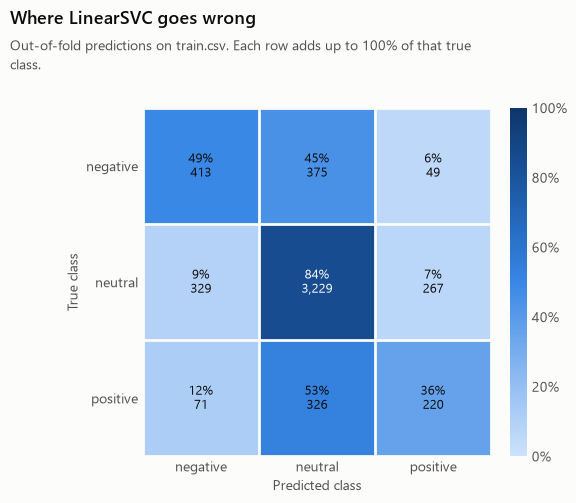

**Findings**

- Recall per class: negative 49%, neutral 84%, positive 36%.
- Most common mistake: 53% of true positive rows are predicted as neutral.

In [12]:
report = pd.DataFrame(
    classification_report(y, main_result["oof_pred"], labels=[0, 1, 2], target_names=label_names, output_dict=True)
).T
display(report.round(3))

display_order = [1, 2, 0]  # negative, neutral, positive
display_names = [cfg.data.label_names[label] for label in display_order]
counts = confusion_matrix(y, main_result["oof_pred"], labels=display_order)
fig = model_plots.plot_confusion_matrix(
    counts, display_names,
    title=f"Where {MAIN_MODEL} goes wrong",
    subtitle="Out-of-fold predictions on train.csv. Each row adds up to 100% of that true class.",
)
save_figure(fig, "model_confusion_matrix")
plt.show()

shares = counts / counts.sum(axis=1, keepdims=True)
mistakes = [(shares[i, j], display_names[i], display_names[j]) for i in range(3) for j in range(3) if i != j]
share, true_name, predicted_name = max(mistakes)
display(Markdown(
    "**Findings**\n\n"
    "- Recall per class: " + ", ".join(f"{display_names[i]} {shares[i, i]:.0%}" for i in range(3)) + ".\n"
    f"- Most common mistake: {share:.0%} of true {true_name} rows are predicted as {predicted_name}."
))

## 8. Hand the main model to the project

Why `LinearSVC` is the one the project ships:

- **Best score.** It leads the tuned table on the capstone metric, weighted F1, on the same 5 folds every model saw.
- **Small classes.** Its macro F1 is the best of the top 3, so the 12% positive and 16% negative rows are not simply
  given away to the neutral majority.
- **Stable and cheap.** The lowest spread across folds of the three, and seconds — not minutes — to refit, so the
  whole pipeline can be rebuilt from raw CSVs on this laptop.
- **Explainable.** A linear model on TF-IDF has one weight per word, so a prediction can be traced back to the words
  in the drug window — which matters for a medical use case and for the viva.

The cell below writes what the project needs to rebuild it — estimator class, tuned hyperparameters, feature
representation and its cross-validation scores — to `artifacts/model/best_model_config.json`. Fitting it on all
5,279 training rows and predicting `test.csv` is then the job of the project scripts, not of this notebook:

```bash
uv run python main.py train     # fits the pipeline on the full training data
uv run python main.py evaluate  # out-of-fold report, error analysis, ablations
uv run python main.py predict   # writes artifacts/submission/predictions.csv
```

In [13]:
def changed_params(model):
    """Only the settings that differ from the estimator's defaults, so the saved config stays readable."""
    defaults = type(model)().get_params()
    return {key: value for key, value in model.get_params().items() if value != defaults.get(key)}


config = {
    "model": MAIN_MODEL,
    "estimator": type(main_model).__name__,
    "params": changed_params(main_model),
    "representation": representation[MAIN_MODEL],
    "text_column": TEXT_COLUMN,
    "sample_weight": MAIN_MODEL in NEEDS_SAMPLE_WEIGHT,
    "cv_metrics": dict(zip(METRICS, main_result["valid"])),
    "fold_f1_std": main_result["fold_f1_std"],
    "selection": {
        "screened_models": list(models),
        "screening_rows": len(half),
        "top3": top3,
        "tuned_trials": {name: int((pd.concat(trial_tables)["model"] == name).sum()) for name in top3},
        "rule": "highest out-of-fold weighted F1; ties within one fold std broken by macro F1, then fit time",
        "rule_pick": rule_pick,
    },
}
save_json(config, cfg.artifacts.model_dir / BEST_CONFIG_FILE)
print(json.dumps(config, indent=2, default=float))

{
  "model": "LinearSVC",
  "estimator": "LinearSVC",
  "params": {
    "C": 0.08468008575248333,
    "class_weight": "balanced",
    "max_iter": 20000
  },
  "representation": "sparse",
  "text_column": "ctx_k1",
  "sample_weight": false,
  "cv_metrics": {
    "accuracy": 0.7315779503693881,
    "f1_weighted": 0.7273618243711768,
    "f1_macro": 0.5716574353824081,
    "recall_macro": 0.5647253129228819,
    "roc_auc_ovr": 0.7835212038999769
  },
  "fold_f1_std": 0.004311836858464202,
  "selection": {
    "screened_models": [
      "LogisticRegression",
      "LinearSVC",
      "ComplementNB",
      "SVC",
      "KNN",
      "DecisionTree",
      "RandomForest",
      "GradientBoosting",
      "LightGBM",
      "XGBoost"
    ],
    "screening_rows": 2639,
    "top3": [
      "LinearSVC",
      "XGBoost",
      "LogisticRegression"
    ],
    "tuned_trials": {
      "LinearSVC": 4,
      "XGBoost": 5,
      "LogisticRegression": 12
    },
    "rule": "highest out-of-fold weighted F1; t

## 9. Outputs

| File | Contents |
|---|---|
| `artifacts/reports/model_screening_half.csv` | Base training of the 10 models on half of the data |
| `artifacts/reports/tuning_trials.csv` | Every Optuna trial for the top 3 |
| `artifacts/reports/tuned_top3.csv` | Tuned top 3 on the full training data |
| `artifacts/model/best_model_config.json` | The main model: estimator, hyperparameters, features, CV scores |
| `artifacts/reports/figures/model_screening_half.png`, `model_confusion_matrix.png` | Figures for the slides |

`main.py train` reads the config file, refits the whole pipeline on all 5,279 training rows and saves
`artifacts/model/best_model.pkl` with a model card; `main.py predict` writes
`artifacts/submission/predictions.csv`.